# 03 — Promo calendar + lag imputation

Build (Customer × Brand × YearMonth) promo calendar from TPR chargebacks. For TPR rows with no MM/YY in the description, impute promo_ym by subtracting the median doc_date lag.

**Upstream:** `tpr_with_brand.parquet` from `02_brand.ipynb`.

**Outputs:**
- `promo_cal.parquet` — unique `(CUSTNMBR, brand, promo_ym)` tuples. `promo_ym` is serialized as `'YYYY-MM'` string; round-trip via `pd.PeriodIndex(..., freq='M')`.
- `promo_lag_meta.parquet` — one-row table holding the fitted `median_lag_days` so downstream steps don't re-fit.

**Filter step**: not every chargeback is a TPR. Cause code `CRED02` bundles real scan-downs with publication / shelf-talker / catalog / trade-show / admin fees that don't change the invoice price. `filter_true_tpr` (in `src/promo_cal.py`) keeps only rows whose cause code or Item Description signals a per-unit price cut. Fee-only rows are dropped so downstream `is_promo` fires on real promo windows, not marketing invoices.

**Promoted to** `src/promo_cal.py` — this notebook just imports `classify_chargeback`, `filter_true_tpr`, `fit_median_lag`, `impute_promo_ym`, `build_promo_calendar`.

## 1. Imports

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

## 2. Load upstream

In [2]:
tpr = pd.read_parquet(ART / 'tpr_with_brand.parquet')
print(f'tpr: {tpr.shape}')
print(f'columns: {list(tpr.columns)}')
print(f'brand null: {tpr["brand"].isna().sum()}  ({tpr["brand"].isna().mean()*100:.1f}%)')

tpr: (6868, 14)
columns: ['Location Code', 'Salesperson ID', 'Customer Number', 'City from Sales Transaction', 'State from Sales Transaction', 'SOP Type', 'SOP Number', 'Customer PO Number', 'Document Date', 'Cause Code', 'Cause Code Desc', 'Item Description', 'Extended Price', 'brand']
brand null: 849  (12.4%)


## 3. Do the work

Chargeback classification (cause code x kind):
kind        fee  other   tpr
Cause Code                  
CRED-PRO    120     10     0
CRED02      136    324   111
CRED03        1      0  4112
CRED04       58    144    57
CRED05      935     68   642
CRED10-D     59      9    82

input rows        :  6,868
kept (real TPR)   :  5,004  (72.9%)
dropped (fee)     :  1,309  (publication / shelf-talker / trade-show / admin)
dropped (other)   :    555  (no price-cut signal in description)



rows with MM/YY in description : 5,003 / 5,004  (100.0%)

lag_days stats (doc_date - promo_start, on the 5,003 labeled rows):
count    5003.000000
mean      151.580252
std       100.401504
min         7.000000
25%        83.000000
50%       127.000000
75%       194.000000
max      1074.000000

median lag = 127 days   mean = 152 days


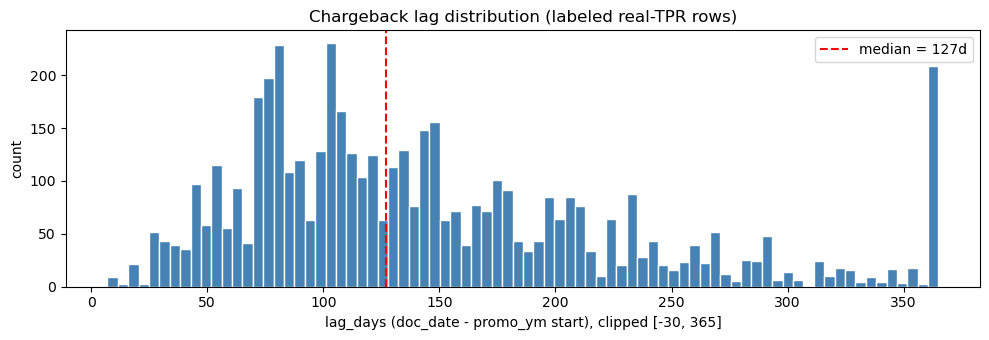


promo_ym coverage (within real-TPR subset):
  regex alone            : 100.0%
  regex + lag fallback   : 100.0%
  delta                  : +0.0pp



promo_cal rows: 1,134
unique customers : 63
unique brands    : 9
unique months    : 46


In [3]:
from src.promo_cal import (
    classify_chargeback,
    filter_true_tpr,
    fit_median_lag,
    impute_promo_ym,
    build_promo_calendar,
)

# ---- Filter chargebacks down to real TPRs -----------------------------------
# CRED02 in particular mixes TPRs with publication / shelf-talker / catalog
# fees. Classify every row so we can report the split.
tpr = tpr.assign(
    kind=[classify_chargeback(d, c)
          for d, c in zip(tpr['Item Description'], tpr['Cause Code'])]
)

print('Chargeback classification (cause code x kind):')
print(tpr.groupby(['Cause Code', 'kind']).size().unstack(fill_value=0))

kept = tpr[tpr['kind'] == 'tpr'].copy()
print(f'\ninput rows        : {len(tpr):>6,}')
print(f'kept (real TPR)   : {len(kept):>6,}  ({len(kept)/len(tpr)*100:.1f}%)')
print(f'dropped (fee)     : {int((tpr["kind"]=="fee").sum()):>6,}  (publication / shelf-talker / trade-show / admin)')
print(f'dropped (other)   : {int((tpr["kind"]=="other").sum()):>6,}  (no price-cut signal in description)')

# ---- Fit + impute on the real-TPR subset ------------------------------------
median_lag = fit_median_lag(kept)
tpr_tagged = impute_promo_ym(kept, median_lag)

raw_cov   = tpr_tagged['promo_ym_raw'].notna().mean()
final_cov = tpr_tagged['promo_ym'].notna().mean()
print(f'\nrows with MM/YY in description : {tpr_tagged["promo_ym_raw"].notna().sum():,} / {len(tpr_tagged):,}  ({raw_cov*100:.1f}%)')

# ---- Lag distribution on labeled subset (for the plot) ----------------------
has_ym = tpr_tagged[tpr_tagged['promo_ym_raw'].notna()].copy()
has_ym['promo_start'] = has_ym['promo_ym_raw'].apply(lambda p: p.to_timestamp())
has_ym['lag_days']    = (pd.to_datetime(has_ym['Document Date']) - has_ym['promo_start']).dt.days

print(f'\nlag_days stats (doc_date - promo_start, on the {len(has_ym):,} labeled rows):')
print(has_ym['lag_days'].describe().to_string())
print(f'\nmedian lag = {median_lag:.0f} days   mean = {has_ym["lag_days"].mean():.0f} days')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(has_ym['lag_days'].clip(-30, 365), bins=80, color='steelblue', edgecolor='white')
ax.axvline(median_lag, color='red', linestyle='--', label=f'median = {median_lag:.0f}d')
ax.set_xlabel('lag_days (doc_date - promo_ym start), clipped [-30, 365]')
ax.set_ylabel('count')
ax.set_title('Chargeback lag distribution (labeled real-TPR rows)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\npromo_ym coverage (within real-TPR subset):')
print(f'  regex alone            : {raw_cov*100:5.1f}%')
print(f'  regex + lag fallback   : {final_cov*100:5.1f}%')
print(f'  delta                  : +{(final_cov-raw_cov)*100:.1f}pp')

# ---- Build (customer x brand x ym) calendar ---------------------------------
# build_promo_calendar applies filter_true_tpr internally; passing the raw
# tpr here gives the same result as passing `kept`.
promo_cal, _ = build_promo_calendar(tpr)

print(f'\npromo_cal rows: {len(promo_cal):,}')
print(f'unique customers : {promo_cal["CUSTNMBR"].nunique():,}')
print(f'unique brands    : {promo_cal["brand"].nunique():,}')
print(f'unique months    : {promo_cal["promo_ym"].nunique():,}')

## 4. Validate

In [4]:
# ---- Month range coverage ----------------------------------------------------
print('Promo months per brand:')
print(promo_cal.groupby('brand')['promo_ym'].nunique().sort_values(ascending=False).to_string())

print('\nMonth range spanned by the calendar:')
print(f'  min : {promo_cal["promo_ym"].min()}')
print(f'  max : {promo_cal["promo_ym"].max()}')

# ---- Rows per customer (spot check) -----------------------------------------
per_cust = promo_cal.groupby('CUSTNMBR').size().describe()
print('\nPromo-tuples per customer:')
print(per_cust.to_string())

# ---- Dup check: should be zero (we dropped duplicates) ----------------------
dups = promo_cal.duplicated(subset=['CUSTNMBR', 'brand', 'promo_ym']).sum()
print(f'\nduplicate (CUSTNMBR, brand, promo_ym) tuples: {dups}')

# ---- Sanity: top 10 promo_ym values (should cluster around 2023-2025) ------
print('\nTop 10 promo_ym counts:')
print(promo_cal['promo_ym'].value_counts().head(10).to_string())

# ---- Spot check: one brand's calendar for the top customer ------------------
top_brand_cust = (
    promo_cal.groupby(['CUSTNMBR', 'brand']).size()
             .sort_values(ascending=False).head(5)
)
print('\nTop 5 (customer, brand) promo-month counts:')
print(top_brand_cust.to_string())

Promo months per brand:
brand
tiger balm               45
ginger chew              41
ginger honey crystals    30
am gsg                   29
bee & flower             24
ginseng                  23
cofixrx                  11
hans honey                9
azzurx                    5

Month range spanned by the calendar:
  min : 2021-01
  max : 2025-12

Promo-tuples per customer:
count    63.000000
mean     18.000000
std      19.169027
min       1.000000
25%       5.000000
50%      11.000000
75%      22.000000
max      99.000000

duplicate (CUSTNMBR, brand, promo_ym) tuples: 0

Top 10 promo_ym counts:
promo_ym
2024-07    51
2025-04    50
2025-01    50
2024-11    47
2025-03    41
2025-05    40
2024-12    39
2024-10    38
2025-08    38
2024-09    37
Freq: M

Top 5 (customer, brand) promo-month counts:
CUSTNMBR  brand      
MTA592A   tiger balm     34
MPE087A   ginger chew    33
WAO556A   tiger balm     33
MIM033A   tiger balm     32
MPE087A   tiger balm     31


## 5. Save downstream artifact

In [5]:
# promo_ym is pd.Period -> parquet can't serialize directly; cast to string 'YYYY-MM'.
# Downstream code can round-trip via pd.PeriodIndex(..., freq='M').
promo_cal_out = promo_cal.copy()
promo_cal_out['promo_ym'] = promo_cal_out['promo_ym'].astype(str)

promo_cal_out.to_parquet(ART / 'promo_cal.parquet')
print(f'promo_cal  {promo_cal_out.shape}  -> promo_cal.parquet')

# Also persist the learned median lag so downstream steps (tagging, backfilling)
# can reuse the same number without re-fitting.
lag_meta = pd.DataFrame({'key': ['median_lag_days'], 'value': [median_lag]})
lag_meta.to_parquet(ART / 'promo_lag_meta.parquet')
print(f'lag_meta   {lag_meta.shape}  -> promo_lag_meta.parquet  (median_lag={median_lag:.0f}d)')

promo_cal  (1134, 3)  -> promo_cal.parquet
lag_meta   (1, 2)  -> promo_lag_meta.parquet  (median_lag=127d)


## 6. Promote

Done — logic lives in `src/promo_cal.py`. Public API: `extract_promo_ym`, `fit_median_lag`, `impute_promo_ym`, `build_promo_calendar`. Downstream steps (05_tag_transactions) should import from there.